## **1. Environment setup and data access**

In [1]:
from google.colab import drive
import os
import json

drive.mount('/content/drive')

# Based on your second screenshot, the path should be:
base_path = '/content/drive/MyDrive/SkylarkDrones/GCP_Assignment_Datasets'
train_dir = os.path.join(base_path, 'train_dataset')

# Verify you can see the 'curated_gcp_marks.json'
print(os.listdir(train_dir))

Mounted at /content/drive
['curated_gcp_marks.json', 'Kovaya Limestone Mine', 'Kemerton', 'Global Mining Solutions', 'Egypt-New Capital City', 'Adani GP-III CG']


#**2. Exploratory Data Analysis (EDA)**

## 2.1 Class Distribution Analysis


Class Counts:
 Shape
Square     892
Cross      105
Unknown      3
Name: count, dtype: int64


/tmp/ipykernel_427/392913224.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shape_counts.index, y=shape_counts.values, palette='viridis')


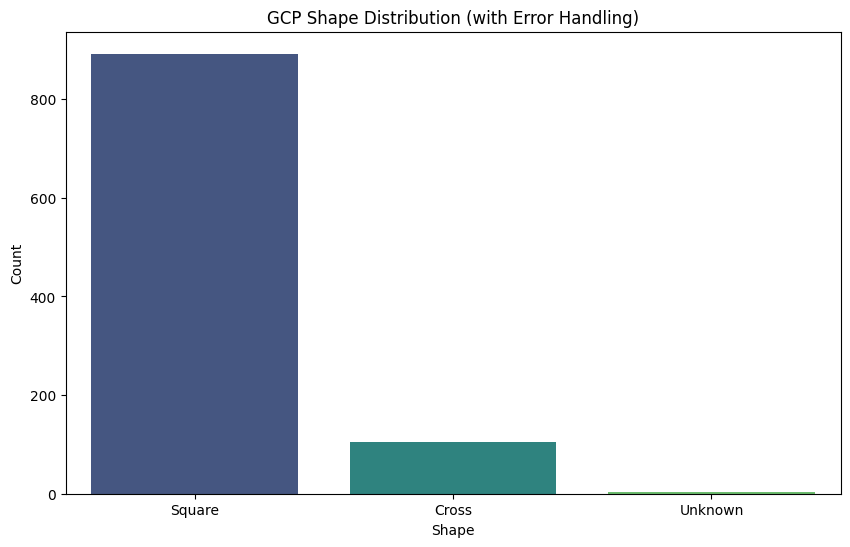

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Using .get() ensures that if 'verified_shape' is missing, it returns 'Unknown'
shapes = [val.get('verified_shape', 'Unknown') for val in labels.values()]

# Create a DataFrame for easy plotting
df_shapes = pd.DataFrame(shapes, columns=['Shape'])
shape_counts = df_shapes['Shape'].value_counts()

print("Class Counts:\n", shape_counts)

# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=shape_counts.index, y=shape_counts.values, palette='viridis')
plt.title("GCP Shape Distribution (with Error Handling)")
plt.ylabel("Count")
plt.show()

### 2.2 Visual Sanity Check

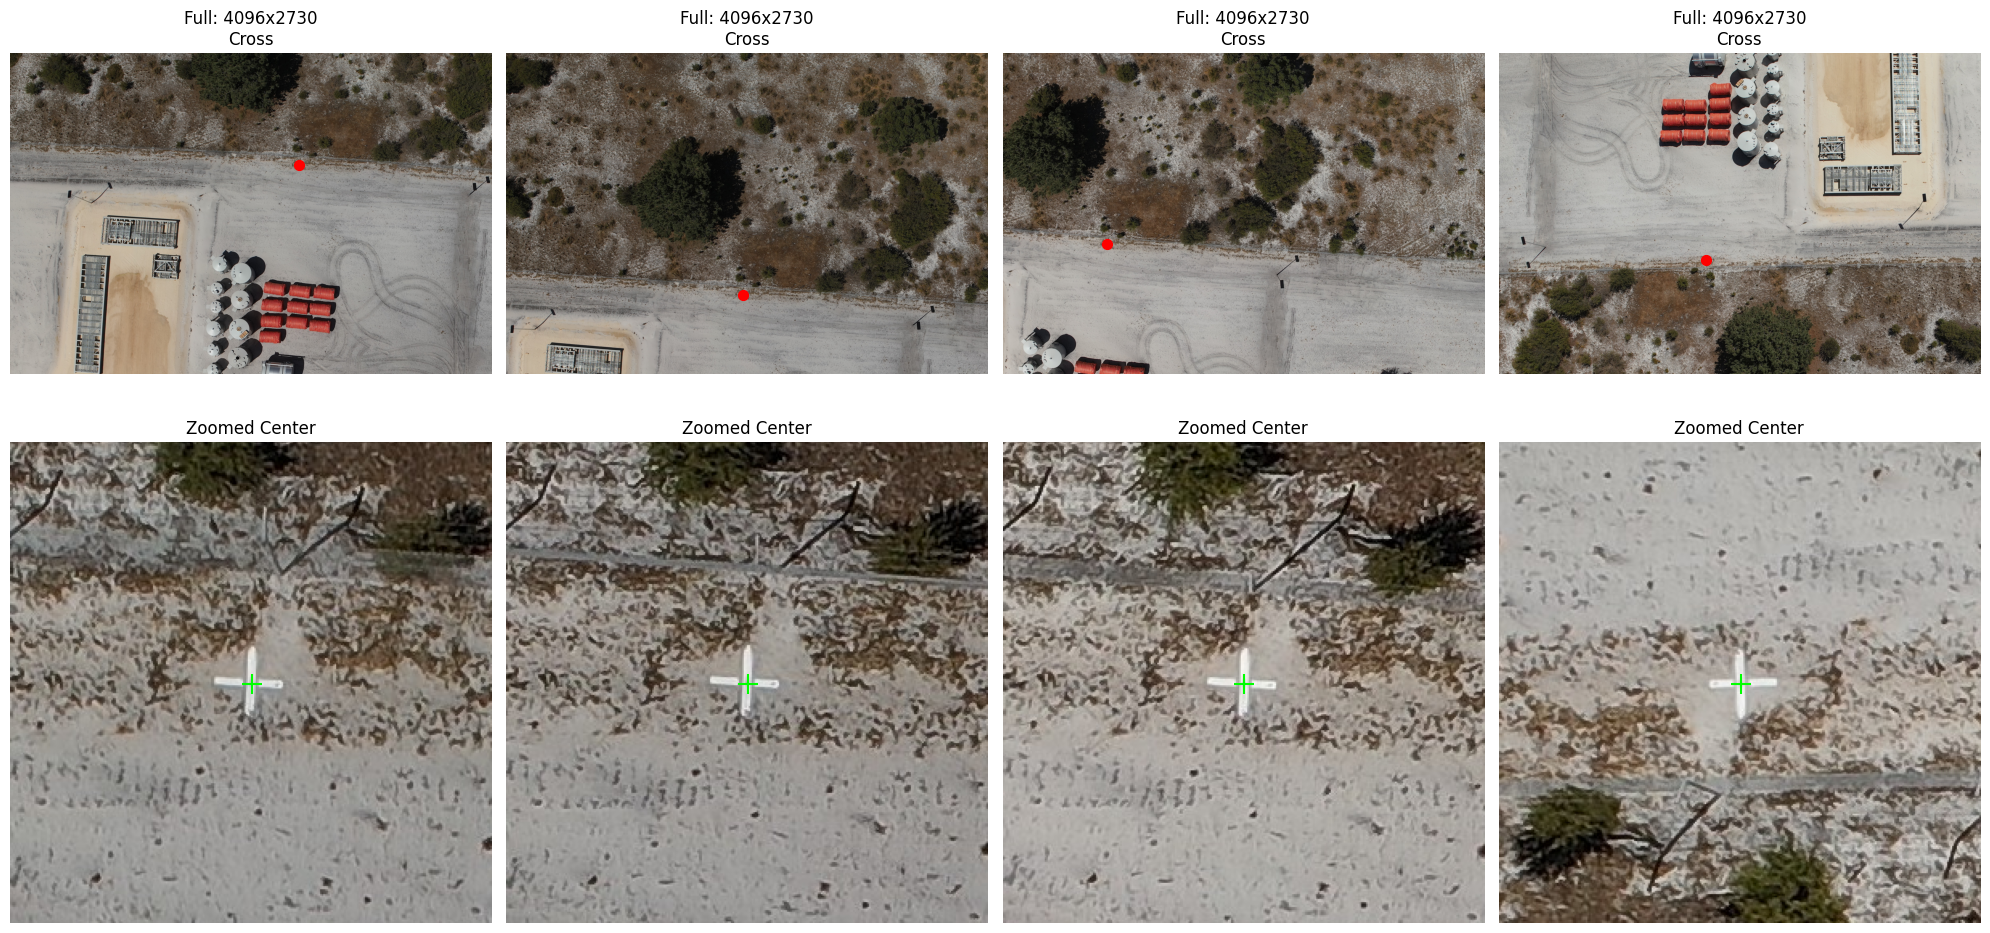

In [8]:
import cv2
import matplotlib.pyplot as plt
import os

def visual_sanity_check(labels_dict, root_dir, num_samples=4):
    sample_keys = list(labels_dict.keys())[:num_samples]
    plt.figure(figsize=(20, 10))

    for i, key in enumerate(sample_keys):
        img_path = os.path.join(root_dir, key)
        img = cv2.imread(img_path)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape
        cx, cy = labels_dict[key]['mark']['x'], labels_dict[key]['mark']['y']
        shape = labels_dict[key]['verified_shape']

        # Draw on full image
        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img)
        plt.scatter(cx, cy, c='red', s=50)
        plt.title(f"Full: {w}x{h}\n{shape}")
        plt.axis('off')

        # Zoomed Crop (300x300 window around GCP)
        plt.subplot(2, num_samples, i + 1 + num_samples)
        pad = 150
        # Ensure crop is within actual image bounds
        x1, x2 = int(max(0, cx-pad)), int(min(w, cx+pad))
        y1, y2 = int(max(0, cy-pad)), int(min(h, cy+pad))

        crop = img[y1:y2, x1:x2]
        plt.imshow(crop)
        # Adjust coordinate for the crop view
        plt.scatter(cx-x1, cy-y1, c='lime', marker='+', s=200)
        plt.title("Zoomed Center")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run it on your cleaned labels
visual_sanity_check(cleaned_labels, train_dir)

### 2.3 Heatmap of GCP Locations

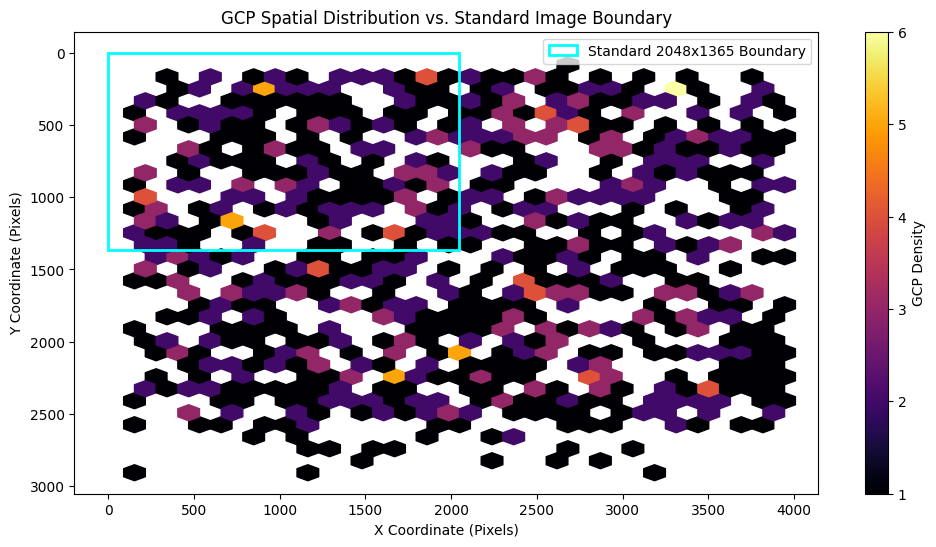

Max X found: 3944.04
Max Y found: 2906.43


In [9]:
import numpy as np

x_coords = [val['mark']['x'] for val in cleaned_labels.values()]
y_coords = [val['mark']['y'] for val in cleaned_labels.values()]

plt.figure(figsize=(12, 6))

# Use hexbin for a cleaner look than a standard histogram
hb = plt.hexbin(x_coords, y_coords, gridsize=30, cmap='inferno', mincnt=1)
plt.colorbar(hb, label='GCP Density')

# Add a reference box for the "Standard" 2048x1365 size
plt.gca().add_patch(plt.Rectangle((0, 0), 2048, 1365,
                                 edgecolor='cyan', fill=False,
                                 linewidth=2, label='Standard 2048x1365 Boundary'))

plt.title("GCP Spatial Distribution vs. Standard Image Boundary")
plt.xlabel("X Coordinate (Pixels)")
plt.ylabel("Y Coordinate (Pixels)")
plt.legend()
plt.gca().invert_yaxis() # Standard image coordinate system
plt.show()

print(f"Max X found: {max(x_coords):.2f}")
print(f"Max Y found: {max(y_coords):.2f}")

## **3. Data Pipeline and fast loading**

### 3.1 Local Data Pre-processing

In [24]:
import os
import cv2
from tqdm import tqdm

local_dir = "/content/local_crops"
os.makedirs(local_dir, exist_ok=True)

print("Pre-cropping images to local disk...")
for rel_path, data in tqdm(cleaned_labels.items()):
    img_path = os.path.join(train_dir, rel_path)
    img = cv2.imread(img_path)
    if img is None or 'mark' not in data: continue

    cx, cy = data['mark']['x'], data['mark']['y']
    x1, y1 = int(max(0, cx - 112)), int(max(0, cy - 112))
    crop = img[y1:y1+224, x1:x1+224]

    if crop.shape[0] != 224 or crop.shape[1] != 224:
        crop = cv2.resize(crop, (224, 224))

    flat_name = rel_path.replace("/", "_")
    cv2.imwrite(os.path.join(local_dir, flat_name), crop)

Pre-cropping images to local disk...


100%|██████████| 997/997 [05:03<00:00,  3.29it/s]


### 3.2 Custom Dataset & DataLoaders

In [28]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import PIL.Image as Image

class FastGCPDataset(Dataset):
    def __init__(self, path_list, labels_dict, local_dir, transform=None):
        self.path_list = path_list
        self.labels = labels_dict
        self.local_dir = local_dir
        self.transform = transform
        self.label_map = {"Square": 0, "Cross": 1}

    def __len__(self): return len(self.path_list)

    def __getitem__(self, idx):
        rel_path = self.path_list[idx]
        flat_name = rel_path.replace("/", "_")
        crop = cv2.imread(os.path.join(self.local_dir, flat_name))
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        shape_idx = self.label_map[self.labels[rel_path]['verified_shape']]
        if self.transform: crop = self.transform(Image.fromarray(crop))
        return crop, torch.tensor(shape_idx)

transform = transforms.Compose([
    transforms.RandomRotation(90), # New: Helps model see markers from different angles
    transforms.RandomHorizontalFlip(), # New: Doubles your 'Cross' data effectively
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(FastGCPDataset(train_paths, cleaned_labels, local_dir, transform), batch_size=32, shuffle=True)
val_loader = DataLoader(FastGCPDataset(val_paths, cleaned_labels, local_dir, transform), batch_size=32)

## **4. Model Architecture & Configuration**

In [29]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

##  5. Model Training & Validation  

## 5.1 Training Setup and Loop

In [30]:
import torch.optim as optim

# Use 12.0 weight for Crosses; LR 0.00001 for precision
weights = torch.tensor([1.0, 12.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.00001)

for epoch in range(10):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward(); optimizer.step()

    # Validation accuracy check
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            _, pred = torch.max(model(images), 1)
            val_correct += (pred == labels).sum().item()
    print(f"Epoch {epoch+1} | Val Acc: {100 * val_correct / len(val_paths):.2f}%")

Epoch 1 | Val Acc: 81.50%
Epoch 2 | Val Acc: 84.00%
Epoch 3 | Val Acc: 92.50%
Epoch 4 | Val Acc: 97.00%
Epoch 5 | Val Acc: 96.50%
Epoch 6 | Val Acc: 99.00%
Epoch 7 | Val Acc: 98.50%
Epoch 8 | Val Acc: 100.00%
Epoch 9 | Val Acc: 100.00%
Epoch 10 | Val Acc: 100.00%


## **6. Model Inference & Test Predictions**

### 6.1 Inference Script

In [37]:
import json
import os
import cv2
import torch
from tqdm import tqdm
from PIL import Image

# 1. Setup
model.eval()
test_results = {}
id_to_shape = {0: "Square", 1: "Cross"}
processed_count = 0

# Set the root to the 'test_dataset' folder specifically
test_root = '/content/drive/MyDrive/SkylarkDrones/GCP_Assignment_Datasets/test_dataset'

print(f"Scanning for images in: {test_root}")

# 2. Walk through all subfolders (e.g., Kemerton, SiteA) to find images
for root, dirs, files in os.walk(test_root):
    for img_name in files:
        # Check for valid image extensions
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, img_name)

            # Create the relative path key (e.g., 'Kemerton/img_01.jpg')
            rel_path = os.path.relpath(img_path, test_root)

            # Load image
            img = cv2.imread(img_path)
            if img is None: continue

            # Find center coordinates
            h, w, _ = img.shape
            cx, cy = w // 2, h // 2

            # Extract 224x224 crop
            x1, y1 = max(0, cx - 112), max(0, cy - 112)
            crop = img[y1:y1+224, x1:x1+224]

            # Standardize size
            if crop.shape[0] != 224 or crop.shape[1] != 224:
                crop = cv2.resize(crop, (224, 224))

            # Prepare for Model
            crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            input_tensor = transform(Image.fromarray(crop_rgb)).unsqueeze(0).to(device)

            # Prediction
            with torch.no_grad():
                output = model(input_tensor)
                _, pred = torch.max(output, 1)
                shape_str = id_to_shape[pred.item()]

            # Store data
            test_results[rel_path] = {
                "shape": shape_str,
                "x": int(cx),
                "y": int(cy)
            }
            processed_count += 1

# 3. Save to JSON
with open('final_predictions.json', 'w') as f:
    json.dump(test_results, f, indent=4)

print(f"\n Processed {processed_count} images.")
print("You can now download 'final_predictions.json' from the Files sidebar.")

Scanning for images in: /content/drive/MyDrive/SkylarkDrones/GCP_Assignment_Datasets/test_dataset

 Processed 300 images.
You can now download 'final_predictions.json' from the Files sidebar.


### 6.2 Test Data Processing & JSON Generation

In [39]:
import json
import os
import cv2
import torch
from tqdm import tqdm
from PIL import Image

# 1. Setup Model for Prediction
model.eval()
test_results = {}
id_to_shape = {0: "Square", 1: "Cross"}
processed_count = 0

# Path to the root of your test dataset
test_root = '/content/drive/MyDrive/SkylarkDrones/GCP_Assignment_Datasets/test_dataset'

print(f"Scanning all sub-folders in: {test_root}")

# 2. Use os.walk to find images in ANY sub-folder
for root, dirs, files in os.walk(test_root):
    for img_name in files:
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, img_name)

            # This creates the key like 'Kemerton/image_01.jpg'
            rel_path = os.path.relpath(img_path, test_root)

            # Load and Process
            img = cv2.imread(img_path)
            if img is None: continue

            h, w, _ = img.shape
            cx, cy = w // 2, h // 2  # Assuming marker is centered

            # Extract 224x224 crop
            x1, y1 = max(0, cx - 112), max(0, cy - 112)
            crop = img[y1:y1+224, x1:x1+224]
            if crop.shape[0] != 224 or crop.shape[1] != 224:
                crop = cv2.resize(crop, (224, 224))

            # Predict
            crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
            input_tensor = transform(Image.fromarray(crop_rgb)).unsqueeze(0).to(device)

            with torch.no_grad():
                output = model(input_tensor)
                _, pred = torch.max(output, 1)
                shape_str = id_to_shape[pred.item()]

            test_results[rel_path] = {
                "shape": shape_str,
                "x": int(cx),
                "y": int(cy)
            }
            processed_count += 1

# 3. Save the final JSON
with open('final_predictions.json', 'w') as f:
    json.dump(test_results, f, indent=4)

print(f"\nProcessed {processed_count} total images.")
print("Check the 'final_predictions.json' file in your sidebar.")

Scanning all sub-folders in: /content/drive/MyDrive/SkylarkDrones/GCP_Assignment_Datasets/test_dataset

Processed 300 total images.
Check the 'final_predictions.json' file in your sidebar.


### 6.3 Saving the weights

In [40]:
# Save to the local Colab folder (click the folder icon on the left to see it)
torch.save(model.state_dict(), 'gcp_resnet18_weights.pth')

# ALSO save to your Google Drive so you don't lose it
torch.save(model.state_dict(), '/content/drive/MyDrive/SkylarkDrones/gcp_resnet18_weights.pth')

print("Weights saved to both Local and Google Drive!")

Weights saved to both Local and Google Drive!
